In [1]:
#1 Install the dependencies
import os
from datetime import datetime
from typing import TypedDict, Optional

# Install required packages
!pip install pdf2image pytesseract chromadb sentence-transformers langchain-groq
!apt-get install poppler-utils tesseract-ocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-proto
    F

In [2]:
#Import the required packages/Dependencies
from pdf2image import convert_from_path
import pytesseract
from PIL import Image
import chromadb
from sentence_transformers import SentenceTransformer

from langgraph.graph import StateGraph, END
from langchain_groq import ChatGroq
from google.colab import userdata

In [3]:
# -----------------------------
# Define state schema
# -----------------------------
class State(TypedDict):
    doc_name: str
    document_text: str
    classification: Optional[str]
    db_result: Optional[str]
    archive_result: Optional[str]
    hitl_result: Optional[str]
    audit_result: Optional[str]
    human_classification: Optional[str] # New field for human classification after HITL

In [4]:
# -----------------------------
# OCR Extraction
# -----------------------------
def extract_text_from_pdf(pdf_path: str) -> str:
    text = ""
    images = convert_from_path(pdf_path)
    for img in images:
        text += pytesseract.image_to_string(img)
    return text.strip()

In [5]:
# -----------------------------
# ChromaDB Setup
# -----------------------------
client = chromadb.Client()
collection = client.get_or_create_collection("cease_requests")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

def store_in_chroma(doc_name: str, text: str):
    embedding = embedder.encode(text).tolist()
    collection.add(
        documents=[text],
        embeddings=[embedding],
        ids=[doc_name]
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
# 2. Setup API Keys
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
# Optional for LangSmith Tracking
os.environ["LANGSMITH_API_KEY"] = userdata.get('LANGSMITH_API_KEY')
os.environ["LANGSMITH_TRACING_V2"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = "RAG Conversational"

Agent Definitions

In [7]:
# -----------------------------
# Classifier Agent
# -----------------------------
def classifier_agent(state: State) -> State:
    doc_text = state["document_text"]
    llm = ChatGroq(model_name="llama-3.3-70b-versatile", temperature=0.7)

    # Ensure the LLM always returns one of the expected classifications
    classification_output = llm.invoke(
        f"""Classify this document.
Document: {doc_text}
Categories: Cease, Uncertain, Irrelevant
Respond with ONLY one word from the categories: Cease, Uncertain, Irrelevant. If unsure, respond 'Uncertain'."""
    ).content.strip()

    # Validate and fallback if necessary
    valid_classifications = {"cease", "uncertain", "irrelevant"}
    if classification_output.lower() in valid_classifications:
        classification = classification_output
    else:
        classification = "Uncertain" # Fallback to uncertain for unexpected outputs

    state["classification"] = classification
    return state

In [8]:
# -----------------------------
# Database Agent
# -----------------------------
def database_agent(state: State) -> State:
    details = {
        "date_received": datetime.now().isoformat(),
        "doc_name": state["doc_name"],
        "extracted_details": state["document_text"][:200]
    }
    state["db_result"] = f"Stored in DB: {details}"
    return state

In [9]:
# -----------------------------
# Archive Agent
# -----------------------------
def archive_agent(state: State) -> State:
    archive_entry = f"{datetime.now().isoformat()} | {state['doc_name']} archived"
    with open("archive.log", "a") as f:
        f.write(archive_entry + "\n")
    state["archive_result"] = archive_entry
    return state

In [10]:
# -----------------------------
# hitl Agent
# -----------------------------
def hitl_agent(state: State) -> State:
    # Simulate human review and classification
    # In a real scenario, this would involve a human interface to get input
    doc_text = state['document_text'].lower()
    if "urgent" in doc_text or "immediate action" in doc_text:
        human_classification = "Cease"
    elif "newsletter" in doc_text or "marketing" in doc_text:
        human_classification = "Irrelevant"
    else:
        human_classification = "Uncertain" # Still uncertain after human review

    state["human_classification"] = human_classification
    state["hitl_result"] = f"Manual review required for {state['doc_name']}. Human classified as: {human_classification}"
    return state

In [11]:
# -----------------------------
# audit Agent
# -----------------------------
def audit_agent(state: State) -> State:
    log_entry = f"{datetime.now().isoformat()} | {state['doc_name']} | {state['classification']}"
    with open("audit.log", "a") as f:
        f.write(log_entry + "\n")
    state["audit_result"] = log_entry
    return state

In [12]:
# -----------------------------
# Workflow Graph
# -----------------------------
graph = StateGraph(State)

graph.add_node("classifier", classifier_agent)
graph.add_node("database", database_agent)
graph.add_node("archive", archive_agent)
graph.add_node("hitl", hitl_agent)
graph.add_node("audit", audit_agent)

graph.set_entry_point("classifier")

graph.add_conditional_edges(
    "classifier",
    lambda state: state["classification"].lower(),
    {
        "cease": "database",
        "irrelevant": "archive",
        "uncertain": "hitl"
    }
)

# New conditional edges after HITL agent based on human classification
graph.add_conditional_edges(
    "hitl",
    lambda state: state["human_classification"].lower() if state.get("human_classification") else "unknown",
    {
        "cease": "database",
        "irrelevant": "archive",
        "uncertain": "archive", # If human review still results in uncertain, go to archive
        "unknown": "archive" # Fallback if human_classification is not set (shouldn't happen)
    }
)

graph.add_edge("database", "audit")
graph.add_edge("archive", "audit")
# Removed direct edge from hitl to audit, now handled by conditional edges
graph.add_edge("audit", END)

workflow = graph.compile()

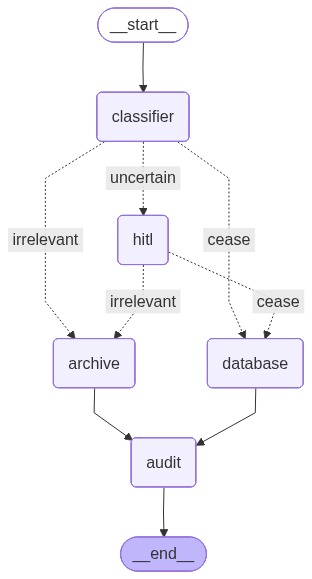

In [13]:
#Graph Visualization
from IPython.display import Image, display

try:
    display(Image(workflow.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies; ignore if it fails in basic environment
    pass

In [14]:
# -----------------------------
# Batch Processor
# -----------------------------
def process_pdf_folder(folder_path: str):
    for filename in os.listdir(folder_path):
        if filename.endswith(".pdf"):
            pdf_path = os.path.join(folder_path, filename)
            print(f"Processing {filename}...")

            # OCR
            doc_text = extract_text_from_pdf(pdf_path)

            # Store in ChromaDB
            store_in_chroma(filename, doc_text)

            # Run workflow
            doc_state = {
                "doc_name": filename,
                "document_text": doc_text
            }
            result = workflow.invoke(doc_state)
            print(result)

# -----------------------------
# Run on a folder of PDFs
# -----------------------------
process_pdf_folder("scanned_pdfs")

Processing bw_doc_1.pdf...
{'doc_name': 'bw_doc_1.pdf', 'document_text': "Abernathy & Rowe - Client Affairs\n\n101 Meridian Avenue, Suite 210\n\nRef: AR/POA/2025/310\n\nRecords Coordinator\nDate: October 11, 2025\n\nNotice Regarding Limited Power of Attorney Representation\n\nWe represent an individual referred to in this correspondence as ‘the Principal.‘ We write\n\nto advise that the Principal has executed a limited Power of Attorney in favor of our\n\nclient, who will act on the Principal's behalf for a narrowly specified set of\n\nadministrative and transactional matters concerning account administration and authorized\ntransfers. The purpose of this notice is informational: to notify your office of a valid\ninstrument granting authority to our client to review account statements, submit\ndocumented instructions limited to account reconciliation, and to liaise with your staff\n\non discrete procedural issues. This communication does not alter or expand any contractual\nobligations

In [15]:
#print the audit log
with open('audit.log', 'r') as f:
    audit_content = f.read()
print(audit_content)

2026-03-21T11:13:49.959985 | bw_doc_1.pdf | Irrelevant
2026-03-21T11:14:04.784973 | LOA8.pdf | Cease
2026-03-21T11:14:08.400342 | bw_doc_3.pdf | Irrelevant
2026-03-21T11:14:12.722856 | notice_5.pdf | Cease
2026-03-21T11:14:18.981410 | LOA6.pdf | Cease
2026-03-21T11:14:23.081061 | notice_4.pdf | Cease
2026-03-21T11:14:30.127789 | LOA5.pdf | Cease
2026-03-21T11:14:35.681158 | LOA3.pdf | Cease
2026-03-21T11:14:41.509262 | notice_3.pdf | Cease
2026-03-21T11:14:48.591836 | LOA2.pdf | Cease
2026-03-21T11:15:03.061017 | LOA9.pdf | Cease
2026-03-21T11:15:07.978583 | bw_doc_5.pdf | Irrelevant
2026-03-21T11:15:12.001651 | notice_2.pdf | Cease
2026-03-21T11:15:15.716711 | bw_doc_2.pdf | Irrelevant
2026-03-21T11:15:22.576433 | LoA1.pdf | Cease
2026-03-21T11:15:38.342769 | LOA7.pdf | Cease
2026-03-21T11:15:44.713829 | LOA4.pdf | Cease
2026-03-21T11:15:48.554915 | bw_doc_4.pdf | Irrelevant
2026-03-21T11:15:52.865337 | notice_1.pdf | Cease



In [16]:
audit_lines = audit_content.strip().split('\n')

classification_counts = {
    "Cease": 0,
    "Irrelevant": 0,
    "Uncertain": 0
}

for line in audit_lines:
    parts = line.split(' | ')
    if len(parts) == 3:
        classification = parts[2].strip()
        if classification in classification_counts:
            classification_counts[classification] += 1

total_documents = len(audit_lines)

print(f"Summary of Document Classifications from Audit Log:")
print(f"Total documents processed: {total_documents}")
for classification, count in classification_counts.items():
    print(f"- {classification}: {count}")

Summary of Document Classifications from Audit Log:
Total documents processed: 19
- Cease: 14
- Irrelevant: 5
- Uncertain: 0
